In [1]:
# making somewhat cleaned-up versions of figures for Figure 4 in the main text + related Supplementary Figures
# note that the figures produced by this code were subsequently edited in Adobe Illustrator
# (arranged into main and supplementary figures & annotated; nothing beyond that was changed)

In [2]:
import os
import re
import importlib
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm
import matplotlib.font_manager

import utils
importlib.reload(utils); utils.versions()

re=2.2.1
pd=2.2.2
np=1.26.4
sp=1.11.4
sns=0.13.2
matplotlib=3.9.2


In [3]:
# pre-processed data:
metadata = utils.metadata 
read_counts_by_cell_line = utils.read_counts_by_cell_line
cell_counts_by_cell_line = utils.cell_counts_by_cell_line

clIDs = utils.clIDs; clIDs_no_spikein = utils.clIDs_no_spikein; clIDs_rep = utils.clIDs_rep; clIDs_not_rejected = utils.clIDs_not_rejected
clID__label = utils.clID__label; clID_replicates__linestyle = utils.clID_replicates__linestyle
clID__color_1 = utils.clID__color_in_vivo_exp1 # based on burden from series one
clID__color_2 = utils.clID__color_in_vivo_exp2 # based on burden from series two

path_to_reads = utils.path_to_reads 
path_to_save_figs = utils.path_to_save_figs

# loading bootstrapped statistics (this might take a while):
# see bootstrapping.ipynb for bootstrapping details
path_to_bootstraps = '../data/bootstraps/'
files = [f for f in os.listdir(path_to_bootstraps) if f.endswith('.npy')]
what__relative_burden_bootstraps = {}
what__n_tumors_bootstraps = {}
what__size_stats_bootstraps = {}
for file in files:
    full_path = os.path.join(path_to_bootstraps, file)
    key = file.replace('.npy', '')
    if file.startswith('burden_bootstrap__'):
        what__relative_burden_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))
    elif file.startswith('n_tumors_bootstrap__'):
        what__n_tumors_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))
    elif file.startswith('sizes_bootstrap__'):
        what__size_stats_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))

### Organ tropism plots (second exp.)

In [4]:
# 3w F1 iv lung samples from exp. one (see bootstrapping.ipynb for details)
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{tag}: {len(samples)} mice in the group.')

clID__mean = utils.get_burden_and_n(samples)[0] # data mean
clID__err = {k: [max(0, clID__mean[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted = [y[0] for y in sorted(clID__mean.items(), key=lambda x: x[-1], reverse=True)]


# 3w F1 iv lung samples from exp. two (see bootstrapping.ipynb for details)
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{tag}: {len(samples)} mice in the group.')

clID__mean_2 = utils.get_burden_and_n(samples)[0] # data mean
clID__err_2 = {k: [max(0, clID__mean_2[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_2[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted_2 = [y[0] for y in sorted(clID__mean_2.items(), key=lambda x: x[-1], reverse=True)]

1_20_C57B6129SF1_intravenous_lung: 20 mice in the group.
2_20_C57B6129SF1_intravenous_lung: 10 mice in the group.


In [5]:
# 3w F1 pancreas samples from exp. one (see bootstrapping.ipynb for details)
# all intrapancreatic injections
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'pancreas']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{tag}: {len(samples)} mice in the group.')

clID__mean_pancreas = utils.get_burden_and_n(samples)[0] # data mean
clID__err_pancreas = {k: [max(0, clID__mean_pancreas[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_pancreas[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted_pancreas = [y[0] for y in sorted(clID__mean_pancreas.items(), key=lambda x: x[-1], reverse=True)]

# also pulling out tumor sizes:
mouse_clID_barcode_size_pancreas = utils.convert_barcode_reads_to_cell_counts(samples)

# 3w F1 pancreas samples from exp. two (see bootstrapping.ipynb for details)
# all intrapancreatic injections
what = ['2', 20, 'C57B6/129S F1', 'pancreas']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{tag}: {len(samples)} mice in the group.')

clID__mean_pancreas_2 = utils.get_burden_and_n(samples)[0] # data mean
clID__err_pancreas_2 = {k: [max(0, clID__mean_pancreas_2[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_pancreas_2[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted_pancreas_2 = [y[0] for y in sorted(clID__mean_pancreas_2.items(), key=lambda x: x[-1], reverse=True)]

# also pulling out tumor sizes:
mouse_clID_barcode_size_pancreas_2 = utils.convert_barcode_reads_to_cell_counts(samples)

1_20_C57B6129SF1_intraperitoneal_pancreas: 9 mice in the group.
2_20_C57B6129SF1_pancreas: 8 mice in the group.


In [6]:
# 3w F1 liver samples from exp. one (see bootstrapping.ipynb for details)
# all intraperitoneal injections
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'liver']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{tag}: {len(samples)} mice in the group.')

clID__mean_liver = utils.get_burden_and_n(samples)[0] # data mean
clID__err_liver = {k: [max(0, clID__mean_liver[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_liver[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted_liver = [y[0] for y in sorted(clID__mean_liver.items(), key=lambda x: x[-1], reverse=True)]


# 3w F1 liver samples from exp. two (see bootstrapping.ipynb for details)
# all intrasplenic injections
what = ['2', 20, 'C57B6/129S F1', 'liver']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{tag}: {len(samples)} mice in the group.')

clID__mean_liver_2 = utils.get_burden_and_n(samples)[0] # data mean
clID__err_liver_2 = {k: [max(0, clID__mean_liver_2[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_liver_2[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted_liver_2 = [y[0] for y in sorted(clID__mean_liver_2.items(), key=lambda x: x[-1], reverse=True)]

1_20_C57B6129SF1_intraperitoneal_liver: 8 mice in the group.
2_20_C57B6129SF1_liver: 9 mice in the group.


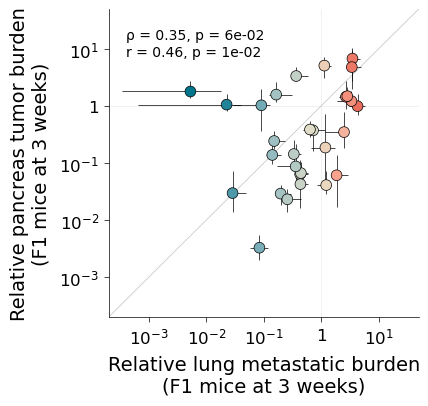

In [7]:
name = 'relative_burden_pancreas_vs_lung_no_immune-rejected_exp2'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_pancreas_2, clID__yerr=clID__err_pancreas_2,
                            clID__x=clID__mean_2, clID__xerr=clID__err_2,
                            xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)',
                            xlims=[2e-4, 0.5e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'],
                            ylims=[2e-4, 0.5e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'])
                           
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

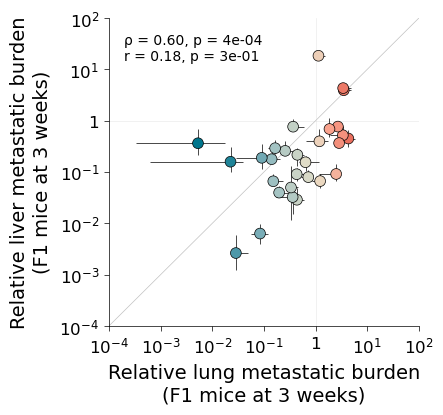

In [8]:
name = 'relative_burden_liver_vs_lung_no_immune-rejected_exp2'
si = 'main'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_liver_2, clID__yerr=clID__err_liver_2,
                            clID__x=clID__mean_2, clID__xerr=clID__err_2,
                            xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                            xlims=[1e-4, 1e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'],
                            ylims=[1e-4, 1e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'])
                           
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

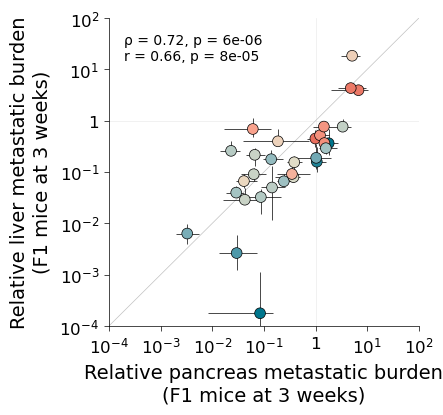

In [9]:
name = 'relative_burden_liver_vs_pancreas_no_immune-rejected_exp2'
si = 'main'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_liver_2, clID__yerr=clID__err_liver_2,
                            clID__x=clID__mean_pancreas_2, clID__xerr=clID__err_pancreas_2,
                            xtitle='Relative pancreas metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                            xlims=[1e-4, 1e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'],
                            ylims=[1e-4, 1e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'])

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

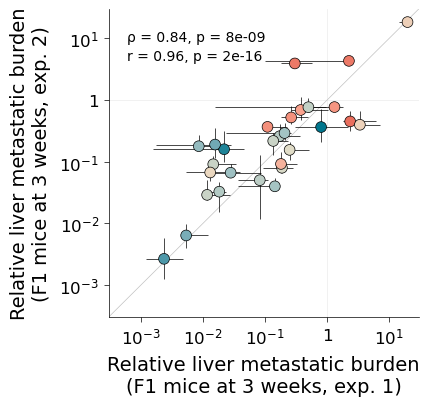

In [10]:
name = 'relative_burden_liver_exp_1_vs_exp2'
si = 'main'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_liver_2, clID__yerr=clID__err_liver_2,
                            clID__x=clID__mean_liver, clID__xerr=clID__err_liver,
                            xtitle='Relative liver metastatic burden\n(F1 mice at 3 weeks, exp. 1)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks, exp. 2)',
                            xlims=[3e-4, 0.3e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'],
                            ylims=[3e-4, 0.3e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'])

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

2_20_C57B6129SF1_intravenous_lung 2_20_C57B6129SF1_liver


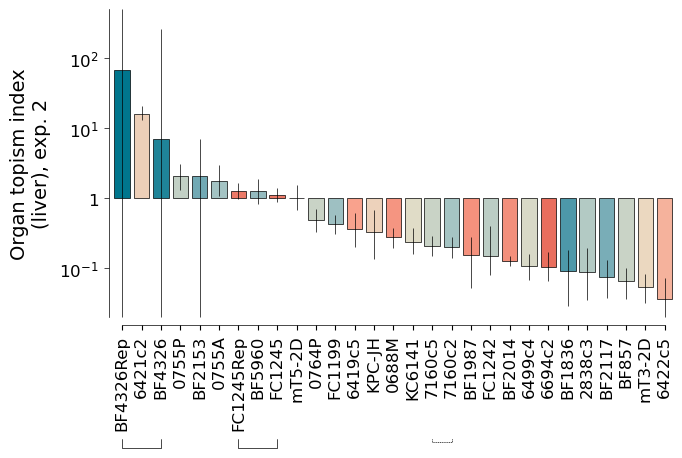

In [11]:
name = 'liver_tropism_exp2'
si = 'main'

index = utils.bootstrap_index(what__relative_burden_bootstraps['burden_bootstrap__' + tag.replace('liver', 'intravenous_lung')], 
                              what__relative_burden_bootstraps['burden_bootstrap__' + tag])
print(tag.replace('liver', 'intravenous_lung'), tag) # make sure these are right

index.pop('AGCA') # not including Panc02
index = {k: v for k, v in index.items() if k in clIDs_not_rejected} # also dropping immune-rejected cell lines

clID__mean_index = {k: clID__mean_liver_2[k] / clID__mean_2[k] for k in index.keys()}
clID__err_index = {k: [np.mean(v) - np.percentile(v, 2.5), np.percentile(v, 97.5) - np.mean(v)] for k, v in index.items()}

clIDs_sorted_index = sorted(index.keys(), key=lambda k: clID__mean_index[k], reverse=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('axes', -0.025))
ax.spines['left'].set_position(('axes', -0.025))

ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.yaxis.set_tick_params(width=0.5)

heights, bottoms, ys, errs, cs = [], [], [], [[], []], []

for i in clIDs_sorted_index:
    cs.append(clID__color_2[i])
    ys.append(clID__mean_index[i])
    errs[0].append(max(0, min(clID__err_index[i][0], ys[-1] - 2e-2))) # be careful here
    errs[1].append(max(0, min(clID__err_index[i][1], 5e2 - ys[-1]))) # and here
    
    if clID__mean_index[i] > 1:
        bottoms.append(1)
        heights.append(clID__mean_index[i] - 1)
    else:
        bottoms.append(clID__mean_index[i])
        heights.append(1 - clID__mean_index[i])

ax.bar(range(len(clIDs_sorted_index)), heights, width=0.8, bottom=bottoms, color=cs,
       edgecolor='black', linewidth=0.5, clip_on=False)

ax.errorbar(range(len(clIDs_sorted_index)), ys, yerr=errs, color='black', linewidth=0.5,
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_yscale('log')
ax.minorticks_off()
ax.set_yticks([1e-1, 1e0, 1e1, 1e2, 1e3])
ax.set_yticklabels(['$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$', '$10^{3}$'], size=12)
ax.set_ylim(2e-2, 5e2)

ax.set_xlim(0, len(clIDs_sorted_index) - 1)
ax.set_xticks(range(len(clIDs_sorted_index)))
ax.set_xticklabels([clID__label[x] for x in clIDs_sorted_index], size=12, rotation=90)

ax.set_ylabel('Organ topism index\n(liver), exp. 2', fontsize=14, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    if not all(k in index for k in key):
        continue
    y = 2e-2 * 0.02
    x = sorted([clIDs_sorted_index.index(key[0]), clIDs_sorted_index.index(key[1])])
    ax.annotate('', xy=(x[0], y), xycoords='data', xytext=(x[1], y), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle=value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

2_20_C57B6129SF1_intravenous_lung 2_20_C57B6129SF1_pancreas


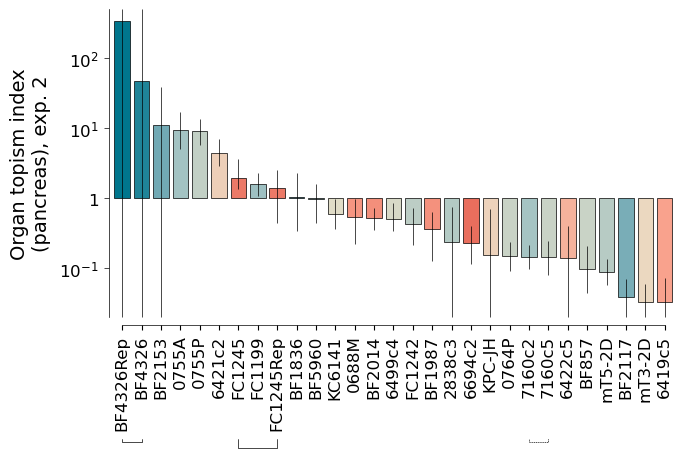

In [12]:
name = 'pancreas_tropism_exp2'
si = 'si'

index = utils.bootstrap_index(what__relative_burden_bootstraps['burden_bootstrap__' + tag.replace('liver', 'intravenous_lung')], 
                              what__relative_burden_bootstraps['burden_bootstrap__' + tag.replace('liver', 'pancreas')])
print(tag.replace('liver', 'intravenous_lung'), tag.replace('liver', 'pancreas')) # make sure these are right

index.pop('AGCA') # not including Panc02
index = {k: v for k, v in index.items() if k in clIDs_not_rejected} # also dropping immune-rejected cell lines

clID__mean_index = {k: clID__mean_pancreas_2[k] / clID__mean_2[k] for k in index.keys()}
clID__err_index = {k: [np.mean(v) - np.percentile(v, 2.5), np.percentile(v, 97.5) - np.mean(v)] for k, v in index.items()}

clIDs_sorted_index = sorted(index.keys(), key=lambda k: clID__mean_index[k], reverse=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('axes', -0.025))
ax.spines['left'].set_position(('axes', -0.025))

ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.yaxis.set_tick_params(width=0.5)

heights, bottoms, ys, errs, cs = [], [], [], [[], []], []

for i in clIDs_sorted_index:
    cs.append(clID__color_2[i])
    ys.append(clID__mean_index[i])
    errs[0].append(max(0, min(clID__err_index[i][0], ys[-1] - 2e-2))) # be careful here
    errs[1].append(max(0, min(clID__err_index[i][1], 5e2 - ys[-1]))) # and here
    
    if clID__mean_index[i] > 1:
        bottoms.append(1)
        heights.append(clID__mean_index[i] - 1)
    else:
        bottoms.append(clID__mean_index[i])
        heights.append(1 - clID__mean_index[i])

ax.bar(range(len(clIDs_sorted_index)), heights, width=0.8, bottom=bottoms, color=cs,
       edgecolor='black', linewidth=0.5, clip_on=False)

ax.errorbar(range(len(clIDs_sorted_index)), ys, yerr=errs, color='black', linewidth=0.5,
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_yscale('log')
ax.minorticks_off()
ax.set_yticks([1e-1, 1e0, 1e1, 1e2, 1e3])
ax.set_yticklabels(['$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$', '$10^{3}$'], size=12)
ax.set_ylim(2e-2, 5e2)

ax.set_xlim(0, len(clIDs_sorted_index) - 1)
ax.set_xticks(range(len(clIDs_sorted_index)))
ax.set_xticklabels([clID__label[x] for x in clIDs_sorted_index], size=12, rotation=90)

ax.set_ylabel('Organ topism index\n(pancreas), exp. 2', fontsize=14, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    if not all(k in index for k in key):
        continue
    y = 2e-2 * 0.02
    x = sorted([clIDs_sorted_index.index(key[0]), clIDs_sorted_index.index(key[1])])
    ax.annotate('', xy=(x[0], y), xycoords='data', xytext=(x[1], y), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle=value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### Correlation matrix and clustering

In [13]:
# making a matrix w/ all correlation coefficients -- computing missing data

# making a list of 3w Rag1 iv lung samples from exp. two
what = ['2', 20, 'Rag1-/-', 'intravenous', 'lung']; tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
print(f'{tag}: {len(samples)} mice in the group.')
clID__mean_rag1_2 = utils.get_burden_and_n(samples)[0]
clID__err_rag1_2 = {k: [max(0, clID__mean_rag1_2[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_rag1_2[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals
clIDs_sorted_rag1_2 = [y[0] for y in sorted(clID__mean_rag1_2.items(), key=lambda x: x[-1], reverse=True)]

# also pulling out tumor sizes:
mouse_clID_barcode_size_rag1 = utils.convert_barcode_reads_to_cell_counts(samples)


# making a list of 3w Rag1 iv lung samples from exp. one
what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']; tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
print(f'{tag}: {len(samples)} mice in the group.')
clID__mean_rag1 = utils.get_burden_and_n(samples)[0]
clID__err_rag1 = {k: [max(0, clID__mean_rag1[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_rag1[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

# also pulling out tumor sizes:
mouse_clID_barcode_size_rag1_2 = utils.convert_barcode_reads_to_cell_counts(samples)


# making a list of 2d F1 iv lung samples from exp. one
what = ['1', 3, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] <= what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
print(f'{tag}: {len(samples)} mice in the group.')
clID__mean_2d = utils.get_burden_and_n(samples)[0]
clID__err_2d = {k: [max(0, clID__mean_2d[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_2d[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

# making a list of 2d F1 iv lung samples from exp. two
what = ['2', 3, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] <= what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
print(f'{tag}: {len(samples)} mice in the group.')
clID__mean_2d_2 = utils.get_burden_and_n(samples)[0]
clID__err_2d_2 = {k: [max(0, clID__mean_2d_2[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_2d_2[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals


# in vitro data
in_vitro_samples = metadata[
    (metadata['experiment'] == 'in vitro') |
    ((metadata['time point, d'] == 0) & (metadata['experiment'] == '1'))
].groupby('time point, d')\
 .apply(lambda df: df.index.tolist(), include_groups=False)

clIDs_ordered_in_vitro = ['AGGT', 'AGCA', 'CTTC', 'AGTC', 'ATCG', 'GAAG', 'CACT', 'ACCT',
                          'CCTT', 'CATG', 'GGAA', 'ACAC', 'GTTG', 'AGAG', 'TTGG', 'TCCA',
                          'CTGT', 'TTCC', 'CAGA', 'GCAT', 'CGTA', 'GGTT', 'ACGA', 'AAGG',
                          'GTAC', 'CGAT', 'GCTA', 'CAAC', 'TGAC', 'ATGC', 'ACTG', 'GTGA',
                          'CCAA'] # clIDs sorted by weighted avg expansion in vitro

clID__in_vitro_exp = {}
clID__in_vitro_exp_err = {}
for clID in clIDs_ordered_in_vitro:
     
    t = 3 # normalizing by the fraction at t = 3 days 
    norm = np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])

    t = 23 # last time point
    y = [read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) / norm for sample_id in in_vitro_samples[t]]
    
    clID__in_vitro_exp[clID] = np.mean(y)
    clID__in_vitro_exp_err[clID] = [np.std(y), np.std(y)]

2_20_Rag1--_intravenous_lung: 7 mice in the group.
1_20_Rag1--_intravenous_lung: 22 mice in the group.
1_3_C57B6129SF1_intravenous_lung: 10 mice in the group.
2_3_C57B6129SF1_intravenous_lung: 7 mice in the group.


In [14]:
# making a matrix w/ all correlation coefficientst

# environments: in vitro, lung 3w f1 (1), lung 3w f1 rag1 (1), lung 3w f1 (2), lung 3w f1 rag1 (2), liver, panc
# make a matrix + cluster 

entities = [[clID__in_vitro_exp[x] for x in clIDs_not_rejected],
            [clID__mean[x] for x in clIDs_not_rejected],
            [clID__mean_rag1[x] for x in clIDs_not_rejected],
            [clID__mean_pancreas[x] for x in clIDs_not_rejected],
            [clID__mean_liver[x] for x in clIDs_not_rejected],
            [clID__mean_2[x] for x in clIDs_not_rejected],
            [clID__mean_rag1_2[x] for x in clIDs_not_rejected],
            [clID__mean_pancreas_2[x] for x in clIDs_not_rejected],
            [clID__mean_liver_2[x] for x in clIDs_not_rejected]]

labels = ['Relative in vitro expansion',
          'Relative lung metastatic burden\n[F1 mice at 3 weeks] Series 1',
          'Relative lung metastatic burden\n[Rag1-/- mice at 3 weeks] Series 1',
          'Relative pancreas metastatic burden Series 1',
          'Relative liver metastatic burden Series 1',
          'Relative lung metastatic burden\n[F1 mice at 3 weeks] Series 2',
          'Relative lung metastatic burden\n[Rag1-/- mice at 3 weeks] Series 2',
          'Relative pancreas tumor burden Series 2',
          'Relative liver metastatis burden Series 2']

n = len(entities)
corr_matrix_r = np.zeros((n, n))
corr_matrix_rho = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):  # compute only upper triangle
        r, _ = sp.stats.pearsonr(entities[i], entities[j])
        rho, _ = sp.stats.spearmanr(entities[i], entities[j])
        corr_matrix_r[i, j] = r
        corr_matrix_r[j, i] = r 
        corr_matrix_rho[i, j] = rho
        corr_matrix_rho[j, i] = rho

corr_matrix_r = pd.DataFrame(corr_matrix_r, index=labels, columns=labels)
corr_matrix_rho = pd.DataFrame(corr_matrix_rho, index=labels, columns=labels)


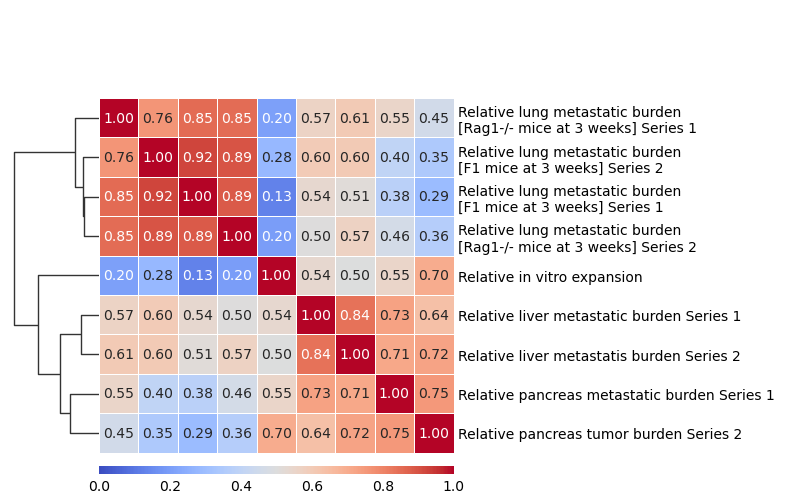

In [15]:
name = 'spearman_rho_corr'
si = 'main'

ax = sns.clustermap(corr_matrix_rho, cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=0, vmax=1), 
                    annot=True, fmt='.2f', linewidths=0.5,
                    figsize=(8, 8), dendrogram_ratio=(0.2, 0.2), 
                    cbar_pos=(0.1305, 0.4, 0.443, 0.01), cbar_kws={'orientation': 'horizontal'})

ax.tick_params(axis='both', which='both', length=0) 
ax.ax_heatmap.set_xticklabels([]);
ax.ax_col_dendrogram.collections[0].set_linewidth(0)
ax.ax_row_dendrogram.collections[0].set_linewidth(1)

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

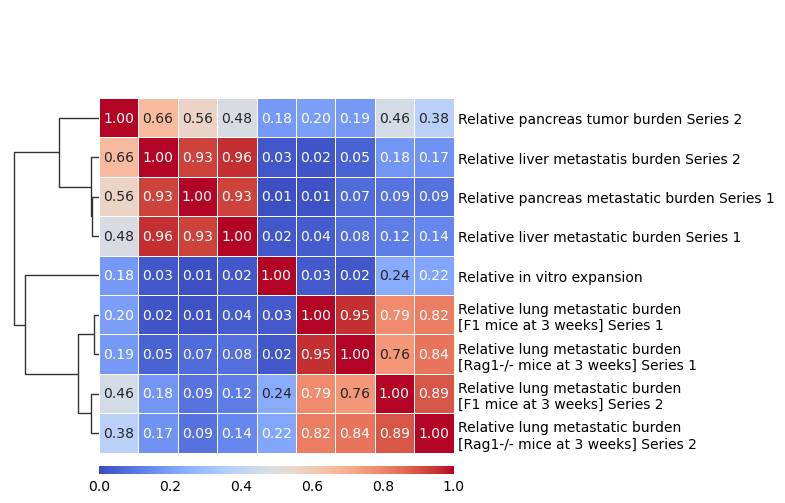

In [16]:
name = 'pearsons_r_corr'
si = 'si'

ax = sns.clustermap(corr_matrix_r, cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=0, vmax=1), 
                    annot=True, fmt='.2f', linewidths=0.5,
                    figsize=(8, 8), dendrogram_ratio=(0.2, 0.2), 
                    cbar_pos=(0.1305, 0.4, 0.443, 0.01), cbar_kws={'orientation': 'horizontal'})

ax.tick_params(axis='both', which='both', length=0) 
ax.ax_heatmap.set_xticklabels([]);
ax.ax_col_dendrogram.collections[0].set_linewidth(0)
ax.ax_row_dendrogram.collections[0].set_linewidth(1)

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

#### Supplementary burden plots

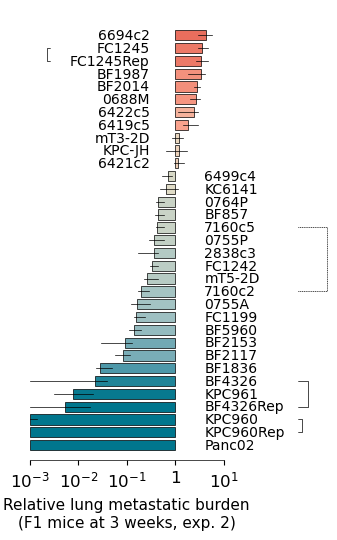

In [17]:
name = 'relative_burden_3w_f1_lung_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_2_r = clIDs_sorted_2[::-1]
widths, lefts, cs = [], [], []

c = 0
for i in clIDs_sorted_2_r:
    # parsing out bootstrapped data
    mean = clID__mean_2[i]
    err = clID__err_2[i]

    cs.append(clID__color_2[i])

    # clipping error bars on the left by hand
    if mean - err[0] < 1e-3:
        x_min = 1e-3
    else: 
        x_min = mean - err[0]
    if mean + err[1] < 1e-3:
        x_max = 1e-3
    else: x_max = mean + err[1]
        
    plt.plot([x_min, x_max], [c, c], color='black', linewidth=0.5, zorder=1e2, clip_on=False)
        
    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1

ax.barh(range(len(clIDs_sorted_2_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative lung metastatic burden\n(F1 mice at 3 weeks, exp. 2)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted_2.index(key[0]) + 0.5, clIDs_sorted_2.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_2_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_2_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

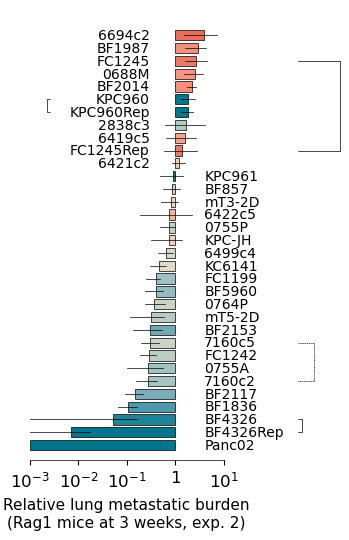

In [18]:
name = 'relative_burden_3w_rag1_lung_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_rag1_2_r = clIDs_sorted_rag1_2[::-1]
widths, lefts, cs = [], [], []

c = 0
for i in clIDs_sorted_rag1_2_r:
    # parsing out bootstrapped data
    mean = clID__mean_rag1_2[i]
    err = clID__err_rag1_2[i]

    cs.append(clID__color_2[i])

    # clipping error bars on the left by hand
    if mean - err[0] < 1e-3:
        x_min = 1e-3
    else: 
        x_min = mean - err[0]
    if mean + err[1] < 1e-3:
        x_max = 1e-3
    else: x_max = mean + err[1]
        
    plt.plot([x_min, x_max], [c, c], color='black', linewidth=0.5, zorder=1e2, clip_on=False)

    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1


ax.barh(range(len(clIDs_sorted_rag1_2_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative lung metastatic burden\n(Rag1 mice at 3 weeks, exp. 2)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted_rag1_2.index(key[0]) + 0.5, clIDs_sorted_rag1_2.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_rag1_2_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_rag1_2_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

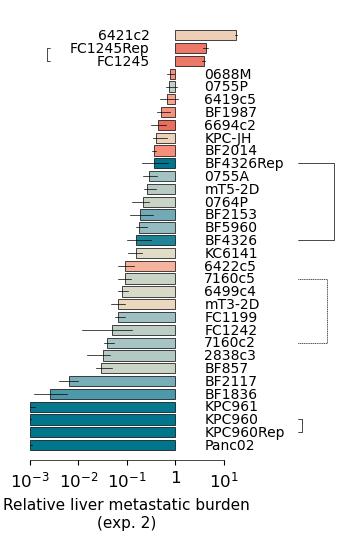

In [19]:
name = 'relative_burden_liver_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_liver_2_r = clIDs_sorted_liver_2[::-1]
widths, lefts, cs = [], [], []

c = 0
for i in clIDs_sorted_liver_2_r:
    # parsing out bootstrapped data
    mean = clID__mean_liver_2[i]
    err = clID__err_liver_2[i]

    cs.append(clID__color_2[i])

    # clipping error bars on the left by hand
    if mean - err[0] < 1e-3:
        x_min = 1e-3
    else: 
        x_min = mean - err[0]
    if mean + err[1] < 1e-3:
        x_max = 1e-3
    else: x_max = mean + err[1]
        
    plt.plot([x_min, x_max], [c, c], color='black', linewidth=0.5, zorder=1e2, clip_on=False)
    
    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1


ax.barh(range(len(clIDs_sorted_liver_2_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative liver metastatic burden\n(exp. 2)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted_liver_2.index(key[0]) + 0.5, clIDs_sorted_liver_2.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_liver_2_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_liver_2_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

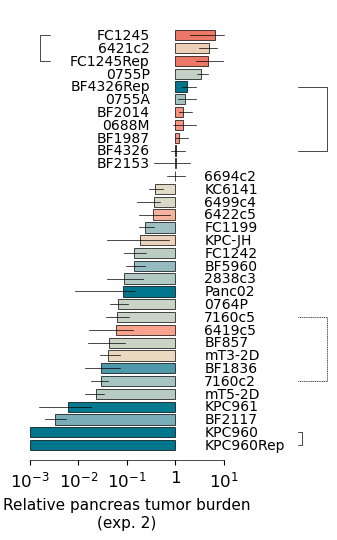

In [20]:
name = 'relative_burden_pancreas_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_pancreas_2_r = clIDs_sorted_pancreas_2[::-1]
widths, lefts, cs = [], [], []

c = 0
for i in clIDs_sorted_pancreas_2_r:
    # parsing out bootstrapped data
    mean = clID__mean_pancreas_2[i]
    err = clID__err_pancreas_2[i]

    cs.append(clID__color_2[i])

    # clipping error bars on the left by hand
    if mean - err[0] < 1e-3:
        x_min = 1e-3
    else: 
        x_min = mean - err[0]
    if mean + err[1] < 1e-3:
        x_max = 1e-3
    else: x_max = mean + err[1]
        
    plt.plot([x_min, x_max], [c, c], color='black', linewidth=0.5, zorder=1e2, clip_on=False)
    
    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1


ax.barh(range(len(clIDs_sorted_pancreas_2_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative pancreas tumor burden\n(exp. 2)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted_pancreas_2.index(key[0]) + 0.5, clIDs_sorted_pancreas_2.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_pancreas_2_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_pancreas_2_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

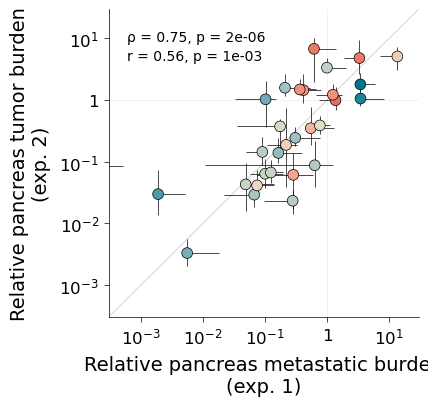

In [21]:
name = 'relative_burden_pancreas_no_immune-rejected_exp_1_vs_exp2'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_pancreas_2, clID__yerr=clID__err_pancreas_2,
                            clID__x=clID__mean_pancreas, clID__xerr=clID__err_pancreas,
                            xtitle='Relative pancreas metastatic burden\n(exp. 1)', ytitle='Relative pancreas tumor burden\n(exp. 2)',
                            xlims=[3e-4, 0.3e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'],
                            ylims=[3e-4, 0.3e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'])

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

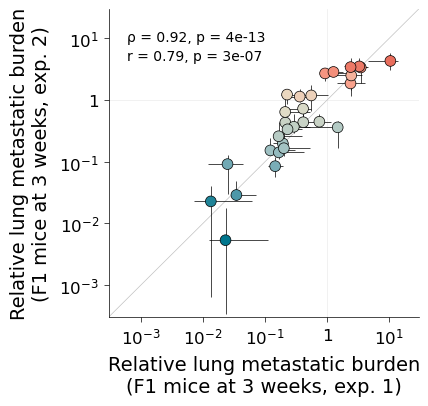

In [22]:
name = 'relative_burden_lung_3w_f1_no_immune-rejected_exp_1_vs_exp2'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_2, clID__yerr=clID__err_2,
                            clID__x=clID__mean, clID__xerr=clID__err,
                            xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks, exp. 1)', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks, exp. 2)',
                            xlims=[3e-4, 0.3e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'],
                            ylims=[3e-4, 0.3e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'])

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

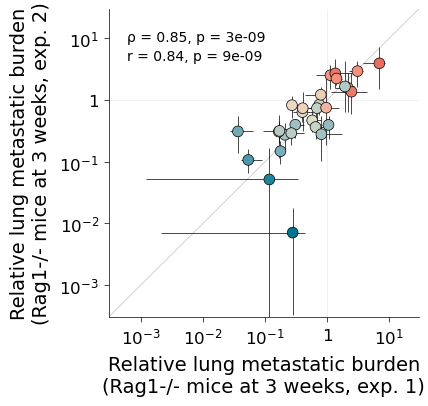

In [23]:
name = 'relative_burden_lung_3w_rag1_no_immune-rejected_exp_1_vs_exp2'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_rag1_2, clID__yerr=clID__err_rag1_2,
                            clID__x=clID__mean_rag1, clID__xerr=clID__err_rag1,
                            xtitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks, exp. 1)', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks, exp. 2)',
                            xlims=[3e-4, 0.3e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'],
                            ylims=[3e-4, 0.3e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$'])

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

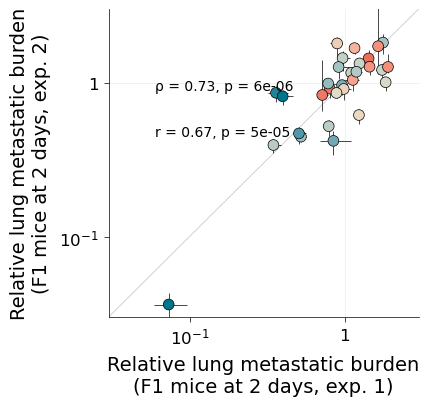

In [24]:
name = 'relative_burden_lung_2d_f1_no_immune-rejected_exp_1_vs_exp2'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_2,
                            clID__y=clID__mean_2d, clID__yerr=clID__err_2d,
                            clID__x=clID__mean_2d_2, clID__xerr=clID__err_2d_2,
                            xtitle='Relative lung metastatic burden\n(F1 mice at 2 days, exp. 1)', ytitle='Relative lung metastatic burden\n(F1 mice at 2 days, exp. 2)',
                            xlims=[3e-2, 0.3e1], xticks=[1e-2, 1e-1, 1e0, 1e1], xlabels=['$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'],
                            ylims=[3e-2, 0.3e1], yticks=[1e-2, 1e-1, 1e0, 1e1], ylabels=['$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'])

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

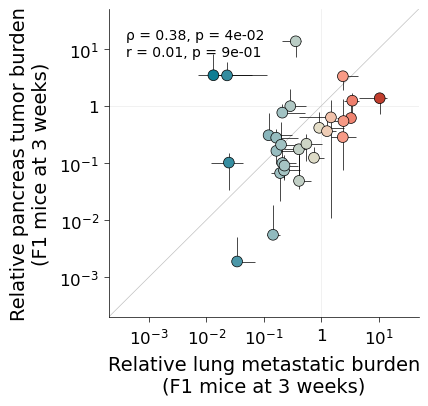

In [25]:
name = 'relative_burden_pancreas_vs_lung_no_immune-rejected_exp1'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_1,
                            clID__y=clID__mean_pancreas, clID__yerr=clID__err_pancreas,
                            clID__x=clID__mean, clID__xerr=clID__err
                            ,
                            xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)',
                            xlims=[2e-4, 0.5e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'],
                            ylims=[2e-4, 0.5e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'])
                           
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

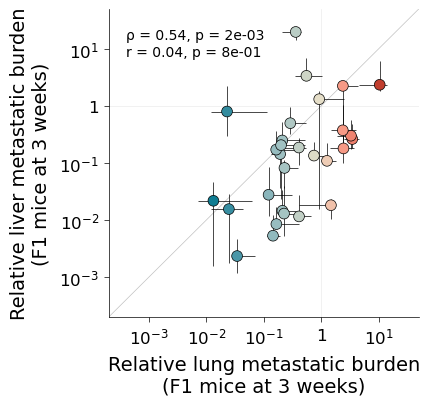

In [26]:
name = 'relative_burden_liver_vs_lung_no_immune-rejected_exp1'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_1,
                            clID__y=clID__mean_liver, clID__yerr=clID__err_liver,
                            clID__x=clID__mean, clID__xerr=clID__err,
                            xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                            xlims=[2e-4, 0.5e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'],
                            ylims=[2e-4, 0.5e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'])
                           
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

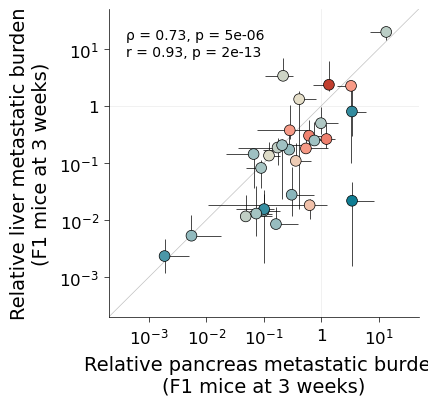

In [27]:
name = 'relative_burden_liver_vs_pancreas_no_immune-rejected_exp1'
si = 'si'

ax = utils.correlation_plot(clIDs_not_rejected, clID__color=clID__color_1,
                            clID__y=clID__mean_liver, clID__yerr=clID__err_liver,
                            clID__x=clID__mean_pancreas, clID__xerr=clID__err_pancreas,
                            xtitle='Relative pancreas metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                            xlims=[2e-4, 0.5e2], xticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], xlabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'],
                            ylims=[2e-4, 0.5e2], yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], ylabels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$'])

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### Metastatic success

In [28]:
# 3w F1 iv lung samples from exp. one (see bootstrapping.ipynb for details)

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# compute proportions from pre-injection samples
pre_injection_samples = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == what[0])]
clID__frac_0 = {clID: np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in pre_injection_samples.index]) for clID in clIDs_no_spikein}

# compute number of cells injected from post-injection samples – be very careful here!!
n_injected_list = [np.mean([metadata.loc[sample_id.split(':')]['initial number of cells'] for sample_id in sample_id.split(':')]) for sample_id in samples]
n_injected_avg = np.mean(n_injected_list)
if len(set(n_injected_list)) != 1:
    print('Double-check numbers!')
else:
    print(round(n_injected_avg), 'cells injected per mouse')

# compute expected initial number of cells per cell line
clID__n_0 = {clID: clID__frac_0[clID] * n_injected_avg for clID in clIDs_no_spikein}

n_mice = len(samples); print(round(n_mice), 'mice')
clID__mean_n = utils.get_burden_and_n(samples)[1] # data mean
clID__mean_success = {k: clID__mean_n[k] / (clID__n_0[k] * n_mice) for k, v in clID__mean_n.items()}
clID__err_success = {k: [max(0, clID__mean_success[k] - (np.percentile(v, 2.5) / (clID__n_0[k] * n_mice))),
                           max(0, (np.percentile(v, 97.5) / (clID__n_0[k] * n_mice) - clID__mean_success[k]))] 
                       for k, v in what__n_tumors_bootstraps['n_tumors_bootstrap__' + tag].items()}

# also pulling out tumor sizes:
mouse_clID_barcode_size = utils.convert_barcode_reads_to_cell_counts(samples)


200000 cells injected per mouse
20 mice


In [29]:
# 3w F1 iv lung samples from exp. two (see bootstrapping.ipynb for details)

what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# compute proportions from pre-injection samples
pre_injection_samples = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == what[0])]
clID__frac_0 = {clID: np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in pre_injection_samples.index]) for clID in clIDs_no_spikein}

# compute number of cells injected from post-injection samples – be very careful here!!
n_injected_list = [np.mean([metadata.loc[sample_id.split(':')]['initial number of cells'] for sample_id in sample_id.split(':')]) for sample_id in samples]
n_injected_avg = np.mean(n_injected_list)
if len(set(n_injected_list)) != 1:
    print('Double-check numbers!')
else:
    print(round(n_injected_avg), 'cells injected per mouse')

# compute expected initial number of cells per cell line
clID__n_0_2 = {clID: clID__frac_0[clID] * n_injected_avg for clID in clIDs_no_spikein}

n_mice = len(samples); print(round(n_mice), 'mice')
clID__mean_n_2 = utils.get_burden_and_n(samples)[1] # data mean
clID__mean_success_2 = {k: clID__mean_n_2[k] / (clID__n_0_2[k] * n_mice) for k, v in clID__mean_n_2.items()}
clID__err_success_2 = {k: [max(0, clID__mean_success_2[k] - (np.percentile(v, 2.5) / (clID__n_0_2[k] * n_mice))),
                           max(0, (np.percentile(v, 97.5) / (clID__n_0_2[k] * n_mice) - clID__mean_success_2[k]))] 
                       for k, v in what__n_tumors_bootstraps['n_tumors_bootstrap__' + tag].items()}

# also pulling out tumor sizes:
mouse_clID_barcode_size_2 = utils.convert_barcode_reads_to_cell_counts(samples)


200000 cells injected per mouse
10 mice


In [30]:
# 3w F1 ip liver samples from exp. one (see bootstrapping.ipynb for details)

what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'liver']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# compute proportions from pre-injection samples
pre_injection_samples = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == what[0])]
clID__frac_0 = {clID: np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in pre_injection_samples.index]) for clID in clIDs_no_spikein}

# compute number of cells injected from post-injection samples – be very careful here!!
n_injected_list = [np.mean([metadata.loc[sample_id.split(':')]['initial number of cells'] for sample_id in sample_id.split(':')]) for sample_id in samples]
n_injected_avg = np.mean(n_injected_list)
if len(set(n_injected_list)) != 1:
    print('Double-check numbers!')
else:
    print(round(n_injected_avg), 'cells injected per mouse')

# compute expected initial number of cells per cell line
clID__n_0_liver = {clID: clID__frac_0[clID] * n_injected_avg for clID in clIDs_no_spikein}

n_mice = len(samples); print(round(n_mice), 'mice')
clID__mean_n_liver = utils.get_burden_and_n(samples)[1] # data mean
clID__mean_success_liver = {k: clID__mean_n_liver[k] / (clID__n_0_liver[k] * n_mice) for k, v in clID__mean_n_liver.items()}
clID__err_success_liver = {k: [max(0, clID__mean_success_liver[k] - (np.percentile(v, 2.5) / (clID__n_0_liver[k] * n_mice))),
                                 max(0, (np.percentile(v, 97.5) / (clID__n_0_liver[k] * n_mice) - clID__mean_success_liver[k]))] 
                             for k, v in what__n_tumors_bootstraps['n_tumors_bootstrap__' + tag].items()}

# also pulling out tumor sizes:
mouse_clID_barcode_size_liver = utils.convert_barcode_reads_to_cell_counts(samples)

2000000 cells injected per mouse
8 mice


In [31]:
# 3w F1 is liver samples from exp. two (see bootstrapping.ipynb for details)

what = ['2', 20, 'C57B6/129S F1', 'liver']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# compute proportions from pre-injection samples
pre_injection_samples = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == what[0])]
clID__frac_0 = {clID: np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in pre_injection_samples.index]) for clID in clIDs_no_spikein}

# compute number of cells injected from post-injection samples – be very careful here!!
n_injected_list = [np.mean([metadata.loc[sample_id.split(':')]['initial number of cells'] for sample_id in sample_id.split(':')]) for sample_id in samples]
n_injected_avg = np.mean(n_injected_list)
if len(set(n_injected_list)) != 1:
    print('Double-check numbers!')
else:
    print(round(n_injected_avg), 'cells injected per mouse')

# compute expected initial number of cells per cell line
clID__n_0_liver_2 = {clID: clID__frac_0[clID] * n_injected_avg for clID in clIDs_no_spikein}

n_mice = len(samples); print(round(n_mice), 'mice')
clID__mean_n_liver_2 = utils.get_burden_and_n(samples)[1] # data mean
clID__mean_success_liver_2 = {k: clID__mean_n_liver_2[k] / (clID__n_0_liver_2[k] * n_mice) for k, v in clID__mean_n_liver_2.items()}
clID__err_success_liver_2 = {k: [max(0, clID__mean_success_liver_2[k] - (np.percentile(v, 2.5) / (clID__n_0_liver_2[k] * n_mice))),
                                 max(0, (np.percentile(v, 97.5) / (clID__n_0_liver_2[k] * n_mice) - clID__mean_success_liver_2[k]))] 
                             for k, v in what__n_tumors_bootstraps['n_tumors_bootstrap__' + tag].items()}

# also pulling out tumor sizes:
mouse_clID_barcode_size_liver_2 = utils.convert_barcode_reads_to_cell_counts(samples)

1000000 cells injected per mouse
9 mice


In [32]:
# 3w F1 ip pancreas samples from exp. one (see bootstrapping.ipynb for details)

what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'pancreas']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# compute proportions from pre-injection samples
pre_injection_samples = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == what[0])]
clID__frac_0 = {clID: np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in pre_injection_samples.index]) for clID in clIDs_no_spikein}

# compute number of cells injected from post-injection samples – be very careful here!!
n_injected_list = [np.mean([metadata.loc[sample_id.split(':')]['initial number of cells'] for sample_id in sample_id.split(':')]) for sample_id in samples]
n_injected_avg = np.mean(n_injected_list)
if len(set(n_injected_list)) != 1:
    print('Double-check numbers!')
else:
    print(round(n_injected_avg), 'cells injected per mouse')

# compute expected initial number of cells per cell line
clID__n_0_pancreas = {clID: clID__frac_0[clID] * n_injected_avg for clID in clIDs_no_spikein}

n_mice = len(samples); print(round(n_mice), 'mice')
clID__mean_n_pancreas = utils.get_burden_and_n(samples)[1] # data mean
clID__mean_success_pancreas = {k: clID__mean_n_pancreas[k] / (clID__n_0_pancreas[k] * n_mice) for k, v in clID__mean_n_pancreas.items()}
clID__err_success_pancreas = {k: [max(0, clID__mean_success_pancreas[k] - (np.percentile(v, 2.5) / (clID__n_0_pancreas[k] * n_mice))),
                                 max(0, (np.percentile(v, 97.5) / (clID__n_0_pancreas[k] * n_mice) - clID__mean_success_pancreas[k]))] 
                             for k, v in what__n_tumors_bootstraps['n_tumors_bootstrap__' + tag].items()}


2000000 cells injected per mouse
9 mice


In [33]:
# 3w F1 is pancreas samples from exp. two (see bootstrapping.ipynb for details)

what = ['2', 20, 'C57B6/129S F1', 'pancreas']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# compute proportions from pre-injection samples
pre_injection_samples = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == what[0])]
clID__frac_0 = {clID: np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in pre_injection_samples.index]) for clID in clIDs_no_spikein}

# compute number of cells injected from post-injection samples – be very careful here!!
n_injected_list = [np.mean([metadata.loc[sample_id.split(':')]['initial number of cells'] for sample_id in sample_id.split(':')]) for sample_id in samples]
n_injected_avg = np.mean(n_injected_list)
if len(set(n_injected_list)) != 1:
    print('Double-check numbers!')
else:
    print(round(n_injected_avg), 'cells injected per mouse')

# compute expected initial number of cells per cell line
clID__n_0_pancreas_2 = {clID: clID__frac_0[clID] * n_injected_avg for clID in clIDs_no_spikein}

n_mice = len(samples); print(round(n_mice), 'mice')
clID__mean_n_pancreas_2 = utils.get_burden_and_n(samples)[1] # data mean
clID__mean_success_pancreas_2 = {k: clID__mean_n_pancreas_2[k] / (clID__n_0_pancreas_2[k] * n_mice) for k, v in clID__mean_n_pancreas_2.items()}
clID__err_success_pancreas_2 = {k: [max(0, clID__mean_success_pancreas_2[k] - (np.percentile(v, 2.5) / (clID__n_0_pancreas_2[k] * n_mice))),
                                    max(0, (np.percentile(v, 97.5) / (clID__n_0_pancreas_2[k] * n_mice) - clID__mean_success_pancreas_2[k]))] 
                                for k, v in what__n_tumors_bootstraps['n_tumors_bootstrap__' + tag].items()}


1000000 cells injected per mouse
8 mice


6421c2 0.19402430307362403 success, %


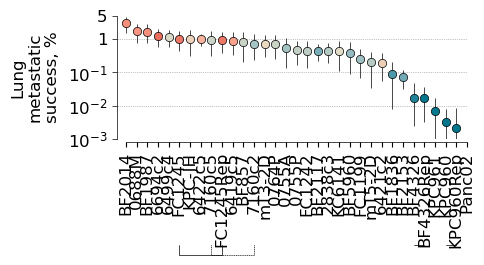

In [34]:
name = 'lung_metastatic_success_log_reordered_3w_f1_exp2'
si = 'main'

fig, ax = plt.subplots(figsize=(4.4, 1.6))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('axes', -0.025))
ax.spines['left'].set_position(('axes', -0.025))

ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.yaxis.set_tick_params(width=0.5)

clIDs_sorted_tmp = [x[0] for x in sorted(clID__mean_success_2.items(), key=lambda x: x[-1], reverse=True)]

for i, clID in enumerate(clIDs_sorted_tmp):
    clip = False if i == 0 else True
    ax.scatter(i, clID__mean_success_2[clID], color=clID__color_2[clID], edgecolor='black', linewidth=0.5, clip_on=clip)
    ax.errorbar(i, clID__mean_success_2[clID], yerr=[[clID__err_success_2[clID][0]], [clID__err_success_2[clID][1]]], color='black', linewidth=0.5, ls='none', zorder=-2)
    if clID == 'GTTG':
        print(clID__label[clID], clID__mean_success_2[clID] * 100, 'success, %')
    
for i in [1e-4, 1e-3, 1e-2]:
    plt.plot([-0.75, len(clIDs_sorted_tmp) - 1], [i, i], ':', color='#898989', linewidth=0.5, zorder=-1e2, clip_on=False)

ax.set_yscale('log')
ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_yticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '1', '5'], size=12)
ax.set_ylim(1e-5, 5e-2)
ax.minorticks_off()

ax.set_xlim(0, len(clIDs_sorted_tmp) - 1)
ax.set_xticks(range(len(clIDs_sorted_tmp)))
ax.set_xticklabels([clID__label[x] for x in clIDs_sorted_tmp], size=12, rotation=90)

ax.set_ylabel('Lung\nmetastatic\nsuccess, %', fontsize=12, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    if key[0] not in clIDs_sorted:
        continue
    y = 0.8e-8
    x = sorted([clIDs_sorted_tmp.index(key[0]), clIDs_sorted_tmp.index(key[1])])
    ax.annotate('', xy=(x[0], y), xycoords='data', xytext=(x[1], y), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle=value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

6421c2 1.7500595663569218 success, %


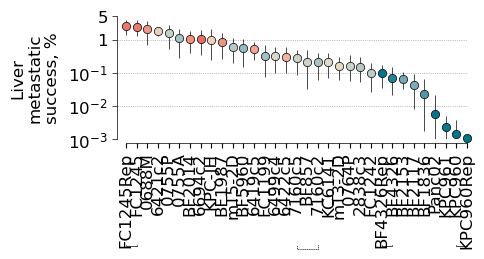

In [35]:
name = 'liver_metastatic_success_log_reordered_exp2'
si = 'main'

fig, ax = plt.subplots(figsize=(4.4, 1.6))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('axes', -0.025))
ax.spines['left'].set_position(('axes', -0.025))

ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.yaxis.set_tick_params(width=0.5)

clIDs_sorted_tmp = [x[0] for x in sorted(clID__mean_success_liver_2.items(), key=lambda x: x[-1], reverse=True)]

for i, clID in enumerate(clIDs_sorted_tmp):
    clip = False if (i == 0 or i == len(clIDs_sorted_tmp) - 1) else True
    ax.scatter(i, clID__mean_success_liver_2[clID], color=clID__color_2[clID], edgecolor='black', linewidth=0.5, clip_on=clip)
    ax.errorbar(i, clID__mean_success_liver_2[clID], yerr=[[clID__err_success_liver_2[clID][0]], [clID__err_success_liver_2[clID][1]]], color='black', linewidth=0.5, ls='none', zorder=-2)
    if clID == 'GTTG':
        print(clID__label[clID], clID__mean_success_liver_2[clID] * 100, 'success, %')

for i in [1e-4, 1e-3, 1e-2]:
    plt.plot([-0.75, len(clIDs_sorted_tmp) - 1], [i, i], ':', color='#898989', linewidth=0.5, zorder=-1e2, clip_on=False)

ax.set_yscale('log')
ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_yticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_ylim(1e-5, 5e-2)
ax.minorticks_off()

ax.set_xlim(0, len(clIDs_sorted_tmp) - 1)
ax.set_xticks(range(len(clIDs_sorted_tmp)))
ax.set_xticklabels([clID__label[x] for x in clIDs_sorted_tmp], size=12, rotation=90)

ax.set_ylabel('Liver\nmetastatic\nsuccess, %', fontsize=12, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    if key[0] not in clIDs_sorted_tmp:
        continue
    y = 0.8e-8
    x = sorted([clIDs_sorted_tmp.index(key[0]), clIDs_sorted_tmp.index(key[1])])
    ax.annotate('', xy=(x[0], y), xycoords='data', xytext=(x[1], y), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle=value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

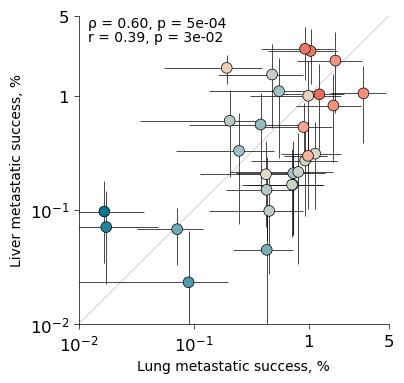

In [36]:
name = 'lung_vs_liver_success_no_immune_rejected_exp2'
si = 'main'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = [clID__mean_success_2[z] for z in clIDs_not_rejected]
ys = [clID__mean_success_liver_2[z] for z in clIDs_not_rejected]

ax.scatter(xs, ys, color=[clID__color_2[z] for z in clIDs_not_rejected], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
ax.errorbar(xs, ys, xerr=[[clID__err_success_2[x][0] for x in clIDs_not_rejected], [clID__err_success_2[x][1] for x in clIDs_not_rejected]],
                    yerr=[[clID__err_success_liver_2[y][0] for y in clIDs_not_rejected], [clID__err_success_liver_2[y][1] for y in clIDs_not_rejected]], color='black', linewidth=0.5, ls='none', zorder=-2)
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(1.2e-4, 0.4e-1, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(1.2e-4, 0.3e-1, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e-5, 5e-2], [1e-5, 5e-2], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
ax.set_xticks([1e-4, 1e-3, 1e-2, 5e-2])
ax.set_xticklabels(['$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_yticks([1e-4, 1e-3, 1e-2, 5e-2])
ax.set_yticklabels(['$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_xlim(1e-4, 5e-2)
ax.set_ylim(1e-4, 5e-2)

ax.set_xlabel("Lung metastatic success, %")
ax.set_ylabel("Liver metastatic success, %")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

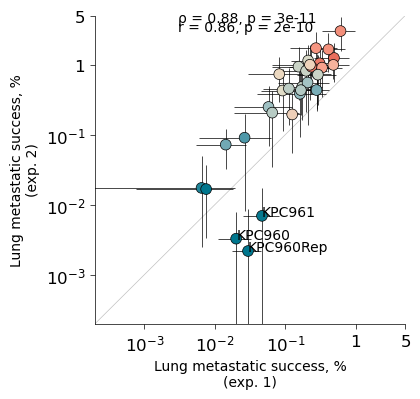

In [37]:
name = 'lung_success_exp1_vs_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = [clID__mean_success[z] for z in clIDs_no_spikein]
ys = [clID__mean_success_2[z] for z in clIDs_no_spikein]

ax.scatter(xs, ys, color=[clID__color_2[z] for z in clIDs_no_spikein], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
ax.errorbar(xs, ys, xerr=[[clID__err_success[x][0] for x in clIDs_no_spikein], [clID__err_success[x][1] for x in clIDs_no_spikein]],
                    yerr=[[clID__err_success_2[y][0] for y in clIDs_no_spikein], [clID__err_success_2[y][1] for y in clIDs_no_spikein]], 
            color='black', linewidth=0.5, ls='none', zorder=-2)

for i in [x for x in clIDs_no_spikein if x not in clIDs_not_rejected]:
    plt.text(clID__mean_success[i], clID__mean_success_2[i], clID__label[i])
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(3e-5, 0.4e-1, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(3e-5, 0.3e-1, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e-6, 5e-2], [1e-6, 5e-2], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
ax.set_xticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_yticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_xlim(2e-6, 5e-2)
ax.set_ylim(2e-6, 5e-2)

ax.set_xlabel("Lung metastatic success, %\n(exp. 1)")
ax.set_ylabel("Lung metastatic success, %\n(exp. 2)")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

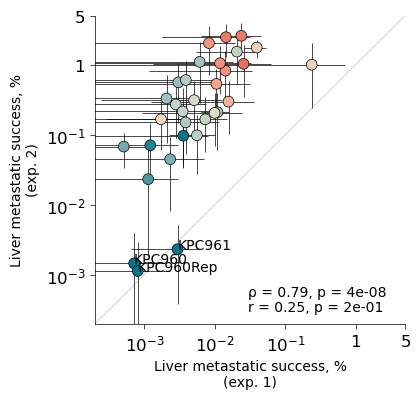

In [38]:
name = 'liver_success_exp1_vs_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = [clID__mean_success_liver[z] for z in clIDs_no_spikein]
ys = [clID__mean_success_liver_2[z] for z in clIDs_no_spikein]

ax.scatter(xs, ys, color=[clID__color_2[z] for z in clIDs_no_spikein], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
ax.errorbar(xs, ys, xerr=[[clID__err_success_liver[x][0] for x in clIDs_no_spikein], [clID__err_success_liver[x][1] for x in clIDs_no_spikein]],
                    yerr=[[clID__err_success_liver_2[y][0] for y in clIDs_no_spikein], [clID__err_success_liver_2[y][1] for y in clIDs_no_spikein]], 
            color='black', linewidth=0.5, ls='none', zorder=-2)

for i in [x for x in clIDs_no_spikein if x not in clIDs_not_rejected]:
    plt.text(clID__mean_success_liver[i], clID__mean_success_liver_2[i], clID__label[i])
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(3e-4, 0.5e-5, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(3e-4, 0.3e-5, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e-6, 5e-2], [1e-6, 5e-2], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
ax.set_xticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_yticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_xlim(2e-6, 5e-2)
ax.set_ylim(2e-6, 5e-2)

ax.set_xlabel("Liver metastatic success, %\n(exp. 1)")
ax.set_ylabel("Liver metastatic success, %\n(exp. 2)")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

KPC960
KPC960Rep


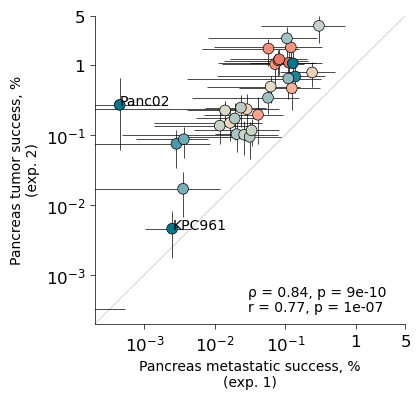

In [39]:
name = 'pancreas_success_exp1_vs_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = [clID__mean_success_pancreas[z] for z in clIDs_no_spikein]
ys = [clID__mean_success_pancreas_2[z] for z in clIDs_no_spikein]

ax.scatter(xs, ys, color=[clID__color_2[z] for z in clIDs_no_spikein], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
ax.errorbar(xs, ys, xerr=[[clID__err_success_pancreas[x][0] for x in clIDs_no_spikein], [clID__err_success_pancreas[x][1] for x in clIDs_no_spikein]],
                    yerr=[[clID__err_success_pancreas_2[y][0] for y in clIDs_no_spikein], [clID__err_success_pancreas_2[y][1] for y in clIDs_no_spikein]], 
            color='black', linewidth=0.5, ls='none', zorder=-2)

for i in [x for x in clIDs_no_spikein if x not in clIDs_not_rejected] + ['AGCA']:
    if min(clID__mean_success_pancreas[i], clID__mean_success_pancreas_2[i]) < 2e-6:
        print(clID__label[i])
        continue
    plt.text(clID__mean_success_pancreas[i], clID__mean_success_pancreas_2[i], clID__label[i])

        
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(3e-4, 0.5e-5, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(3e-4, 0.3e-5, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e-6, 5e-2], [1e-6, 5e-2], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
ax.set_xticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 5e-2])
ax.set_yticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_xlim(2e-6, 5e-2)
ax.set_ylim(2e-6, 5e-2)

ax.set_xlabel("Pancreas metastatic success, %\n(exp. 1)")
ax.set_ylabel("Pancreas tumor success, %\n(exp. 2)")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### Tumor size plots

Panc02


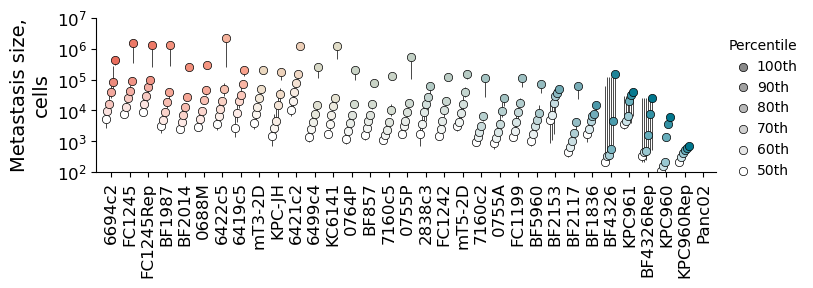

In [40]:
name = 'size_percentiles_3w_f1_lung_exp2'
si = 'si'

what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
medians_2 = {}
medians_err_2 = {}

percentiles = [50, 60, 70, 80, 90, 100]
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted_2):

    rgb = np.array(clID__color_2[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(percentiles))

    sizes = mouse_clID_barcode_size_2.loc[mouse_clID_barcode_size_2.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    if len(sizes) == 0:
        print(clID__label[clID])
        continue

    for j, p in enumerate(percentiles):

        y = np.percentile(sizes, p)

        bootstrapped = what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p]
        yerr_lower = max(0, y - np.percentile(bootstrapped, 2.5))
        yerr_upper = max(0, np.percentile(bootstrapped, 97.5) - y)

        if p == 50:
            medians_2[clID] = y
            medians_err_2[clID] = [[yerr_lower], [yerr_upper]]

        x = i + j * 0.1

        plt.scatter(x, y, color=gradient[j], edgecolor='black', linewidth=0.5, zorder=2)
        plt.errorbar(x, y, yerr=[[yerr_lower], [yerr_upper]], color='black', linewidth=0.5, zorder=1)

gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(percentiles))[::-1]

for j, p in enumerate(percentiles[::-1]):
    plt.scatter(-1, 1, color=gradient[j], edgecolor='black', linewidth=0.5, label=f'{p}th')

plt.yscale('log')
plt.minorticks_off()
plt.legend(frameon=False, bbox_to_anchor=(1, 0.95), ncol=1, handletextpad=0, columnspacing=0.1, title='Percentile')

plt.ylim(1e2, 1e7)
plt.xlim(-0.5, i + j * 0.1 + 0.5)
plt.xticks(0.3 + np.arange(i + 1), [clID__label[x] for x in clIDs_sorted_2], rotation=90, ha='center', size=12)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
plt.yticks(size=12)

plt.ylabel('Metastasis size,\ncells', fontsize=14)

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


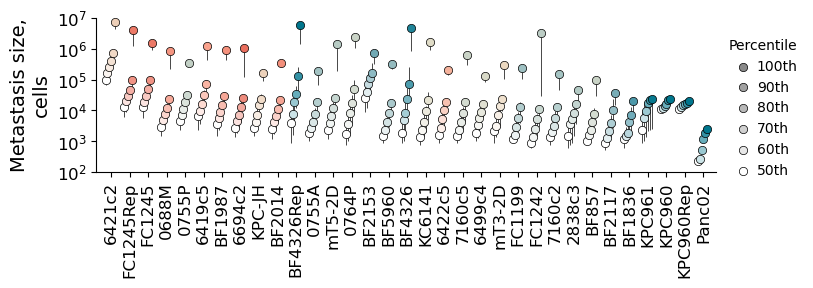

In [41]:
name = 'size_percentiles_liver_exp2'
si = 'si'

what = ['2', 20, 'C57B6/129S F1', 'liver']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
medians_liver_2 = {}
medians_err_liver_2 = {}

percentiles = [50, 60, 70, 80, 90, 100]
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted_liver_2):

    rgb = np.array(clID__color_2[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(percentiles))

    sizes = mouse_clID_barcode_size_liver_2.loc[mouse_clID_barcode_size_liver_2.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    if len(sizes) == 0:
        print(clID__label[clID])
        continue

    for j, p in enumerate(percentiles):

        y = np.percentile(sizes, p)

        bootstrapped = what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p]
        yerr_lower = max(0, y - np.percentile(bootstrapped, 2.5))
        yerr_upper = max(0, np.percentile(bootstrapped, 97.5) - y)

        if p == 50:
            medians_liver_2[clID] = y
            medians_err_liver_2[clID] = [[yerr_lower], [yerr_upper]]

        x = i + j * 0.1

        plt.scatter(x, y, color=gradient[j], edgecolor='black', linewidth=0.5, zorder=2)
        plt.errorbar(x, y, yerr=[[yerr_lower], [yerr_upper]], color='black', linewidth=0.5, zorder=1)

gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(percentiles))[::-1]

for j, p in enumerate(percentiles[::-1]):
    plt.scatter(-1, 1, color=gradient[j], edgecolor='black', linewidth=0.5, label=f'{p}th')

plt.yscale('log')
plt.minorticks_off()
plt.legend(frameon=False, bbox_to_anchor=(1, 0.95), ncol=1, handletextpad=0, columnspacing=0.1, title='Percentile')

plt.ylim(1e2, 1e7)
plt.xlim(-0.5, i + j * 0.1 + 0.5)
plt.xticks(0.3 + np.arange(i + 1), [clID__label[x] for x in clIDs_sorted_liver_2], rotation=90, ha='center', size=12)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
plt.yticks(size=12)

plt.ylabel('Metastasis size,\ncells', fontsize=14)

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


Panc02


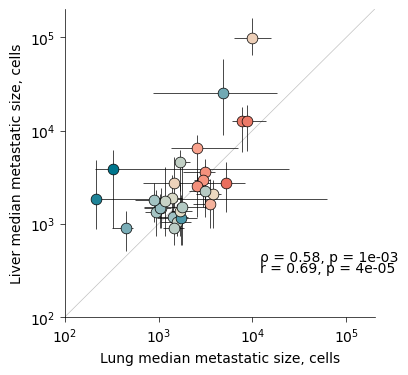

In [42]:
name = 'lung_vs_liver_median_size_no_immune_rejected_exp2'
si = 'main'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = []; ys = []
for clID in clIDs_not_rejected:
    if clID == 'AGCA':
        print(clID__label[clID])
        continue
    
    ax.scatter(medians_2[clID], medians_liver_2[clID], color=clID__color_2[clID], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
    ax.errorbar(medians_2[clID], medians_liver_2[clID], xerr=medians_err_2[clID], yerr=medians_err_liver_2[clID], color='black', linewidth=0.5, ls='none', zorder=-2)

    xs.append(medians_2[clID])
    ys.append(medians_liver_2[clID])
    # plt.text(xs[-1], ys[-1], clID__label[clID])
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(1.2e4, 0.4e3, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(1.2e4, 0.3e3, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e2, 2e5], [1e2, 2e5], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
#ax.set_xticks([1e-4, 1e-3, 1e-2, 5e-2])
#ax.set_xticklabels(['$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
#ax.set_yticks([1e-4, 1e-3, 1e-2, 5e-2])
#ax.set_yticklabels(['$10^{-2}$', '$10^{-1}$', '$1$', '$5$'], size=12)
ax.set_xlim(1e2, 2e5)
ax.set_ylim(1e2, 2e5)

ax.set_xlabel("Lung median metastatic size, cells")
ax.set_ylabel("Liver median metastatic size, cells")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

In [43]:
# pulling out other data for supplementary plots

p = 50

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
medians = {}; medians_err = {}

for i, clID in enumerate(clIDs_no_spikein):
    sizes = mouse_clID_barcode_size.loc[mouse_clID_barcode_size.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    if len(sizes) == 0:
        print(tag, clID__label[clID])
        continue
        
    y = np.percentile(sizes, p)
    bootstrapped = what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p]
    yerr_lower = max(0, y - np.percentile(bootstrapped, 2.5))
    yerr_upper = max(0, np.percentile(bootstrapped, 97.5) - y)

    medians[clID] = y
    medians_err[clID] = [[yerr_lower], [yerr_upper]]


what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'liver']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
medians_liver = {}; medians_err_liver = {}

for i, clID in enumerate(clIDs_no_spikein):
    sizes = mouse_clID_barcode_size_liver.loc[mouse_clID_barcode_size_liver.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    if len(sizes) == 0:
        print(tag, clID__label[clID])
        continue
        
    y = np.percentile(sizes, p)
    bootstrapped = what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p]
    yerr_lower = max(0, y - np.percentile(bootstrapped, 2.5))
    yerr_upper = max(0, np.percentile(bootstrapped, 97.5) - y)

    medians_liver[clID] = y
    medians_err_liver[clID] = [[yerr_lower], [yerr_upper]]


what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'pancreas']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
medians_pancreas = {}; medians_err_pancreas = {}

for i, clID in enumerate(clIDs_no_spikein):
    sizes = mouse_clID_barcode_size_pancreas.loc[mouse_clID_barcode_size_pancreas.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    if len(sizes) == 0:
        print(tag, clID__label[clID])
        continue
        
    y = np.percentile(sizes, p)
    bootstrapped = what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p]
    yerr_lower = max(0, y - np.percentile(bootstrapped, 2.5))
    yerr_upper = max(0, np.percentile(bootstrapped, 97.5) - y)

    medians_pancreas[clID] = y
    medians_err_pancreas[clID] = [[yerr_lower], [yerr_upper]]


what = ['2', 20, 'C57B6/129S F1', 'pancreas']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
medians_pancreas_2 = {}; medians_err_pancreas_2 = {}

for i, clID in enumerate(clIDs_no_spikein):
    sizes = mouse_clID_barcode_size_pancreas_2.loc[mouse_clID_barcode_size_pancreas_2.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    if len(sizes) == 0:
        print(tag, clID__label[clID])
        continue
        
    y = np.percentile(sizes, p)
    bootstrapped = what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p]
    yerr_lower = max(0, y - np.percentile(bootstrapped, 2.5))
    yerr_upper = max(0, np.percentile(bootstrapped, 97.5) - y)

    medians_pancreas_2[clID] = y
    medians_err_pancreas_2[clID] = [[yerr_lower], [yerr_upper]]

  


1_20_C57B6129SF1_intravenous_lung Panc02
1_20_C57B6129SF1_intraperitoneal_liver Panc02
1_20_C57B6129SF1_intraperitoneal_pancreas KPC960Rep


Panc02


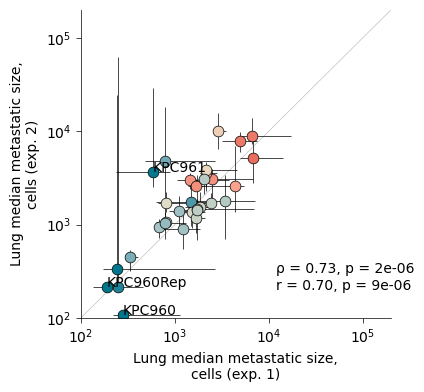

In [44]:
name = 'lung_median_size_3w_f1_exp1_vs_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = []; ys = []
for clID in clIDs_no_spikein:
    if clID == 'AGCA':
        print(clID__label[clID])
        continue
    
    ax.scatter(medians[clID], medians_2[clID], color=clID__color_2[clID], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
    ax.errorbar(medians[clID], medians_2[clID], xerr=medians_err[clID], yerr=medians_err_2[clID], color='black', linewidth=0.5, ls='none', zorder=-2)

    xs.append(medians[clID])
    ys.append(medians_2[clID])
    # plt.text(xs[-1], ys[-1], clID__label[clID])
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(1.2e4, 0.3e3, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(1.2e4, 0.2e3, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e2, 2e5], [1e2, 2e5], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

# labels
for i in [x for x in clIDs_no_spikein if x not in clIDs_not_rejected]:
    plt.text(medians[i], medians_2[i], clID__label[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
ax.set_xlim(1e2, 2e5)
ax.set_ylim(1e2, 2e5)

ax.set_xlabel("Lung median metastatic size,\ncells (exp. 1)")
ax.set_ylabel("Lung median metastatic size,\ncells (exp. 2)")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

Panc02


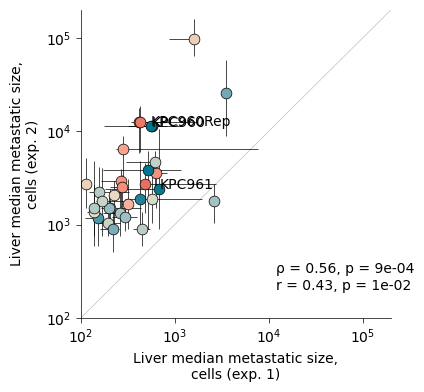

In [45]:
name = 'liver_median_size_exp1_vs_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = []; ys = []
for clID in clIDs_no_spikein:
    if clID == 'AGCA':
        print(clID__label[clID])
        continue
    
    ax.scatter(medians_liver[clID], medians_liver_2[clID], color=clID__color_2[clID], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
    ax.errorbar(medians_liver[clID], medians_liver_2[clID], xerr=medians_err_liver[clID], yerr=medians_err_liver_2[clID], color='black', linewidth=0.5, ls='none', zorder=-2)

    xs.append(medians_liver[clID])
    ys.append(medians_liver_2[clID])
    # plt.text(xs[-1], ys[-1], clID__label[clID])
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(1.2e4, 0.3e3, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(1.2e4, 0.2e3, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e2, 2e5], [1e2, 2e5], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

# labels
for i in [x for x in clIDs_no_spikein if x not in clIDs_not_rejected]:
    plt.text(medians_liver[i], medians_liver_2[i], clID__label[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
ax.set_xlim(1e2, 2e5)
ax.set_ylim(1e2, 2e5)

ax.set_xlabel("Liver median metastatic size,\ncells (exp. 1)")
ax.set_ylabel("Liver median metastatic size,\ncells (exp. 2)")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

KPC960Rep


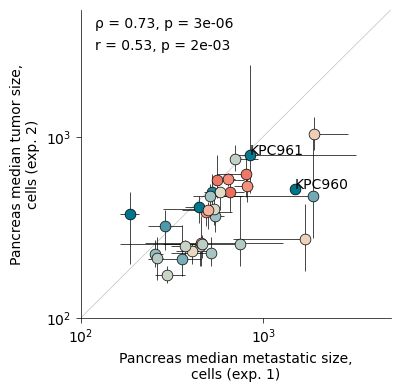

In [46]:
name = 'pancreas_median_size_exp1_vs_exp2'
si = 'si'

fig, ax = plt.subplots(figsize=(4, 4))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.tick_params(width=0.5)

xs = []; ys = []
for clID in clIDs_no_spikein:
    if clID == 'GCAT':
        print(clID__label[clID])
        continue
    
    ax.scatter(medians_pancreas[clID], medians_pancreas_2[clID], color=clID__color_2[clID], s=60, edgecolor='black', linewidth=0.5, alpha=1, zorder=1)
    ax.errorbar(medians_pancreas[clID], medians_pancreas_2[clID], xerr=medians_err_pancreas[clID], yerr=medians_err_pancreas_2[clID], color='black', linewidth=0.5, ls='none', zorder=-2)

    xs.append(medians_pancreas[clID])
    ys.append(medians_pancreas_2[clID])
    # plt.text(xs[-1], ys[-1], clID__label[clID])
    
spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
ax.text(1.2e2, 0.4e4, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
ax.text(1.2e2, 0.3e4, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

ax.plot([1e2, 2e5], [1e2, 2e5], color='#c1c1c1', linewidth=0.5, zorder=-3)  # diagonal line

# labels
for i in [x for x in clIDs_no_spikein if x not in clIDs_not_rejected and x != 'GCAT']:
    plt.text(medians_pancreas[i], medians_pancreas_2[i], clID__label[i])


ax.set_xscale('log')
ax.set_yscale('log')
ax.minorticks_off()
ax.set_xlim(1e2, 5e3)
ax.set_ylim(1e2, 5e3)

ax.set_xlabel("Pancreas median metastatic size,\ncells (exp. 1)")
ax.set_ylabel("Pancreas median tumor size,\ncells (exp. 2)")

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

#### Number of metastases in lung and liver 

10464


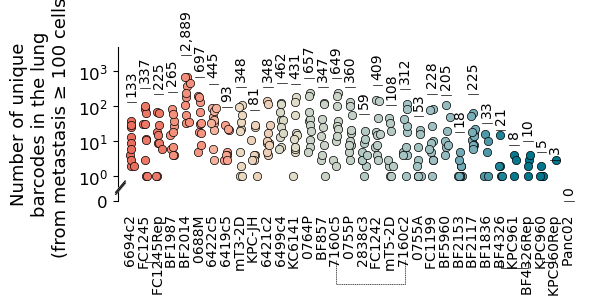

In [47]:
name = 'n_unique_barcodes_lung_3w_f1_exp2'
si = 'si'

plt.figure(figsize=(6, 2))
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_linewidth(0.5)

n = 0

# count unique barcodes per clID per mouse
n_tumors = mouse_clID_barcode_size_2[mouse_clID_barcode_size_2['size'] >= 100].groupby(['mouse', 'clID'])['barcode'].nunique().reset_index(name='n_barcodes')

clID__n_tumors = {clID: [] for clID in clIDs_no_spikein}
for clID in clIDs[1:]:
    values = n_tumors[n_tumors['clID'] == clID]['n_barcodes'].tolist()
    clID__n_tumors[clID].extend(values)

for i, clID in enumerate(clIDs_sorted_2):
    plt.scatter(i + np.random.normal(0, 0.1, len(clID__n_tumors[clID])), [0.2 if x == 0 else x for x in clID__n_tumors[clID]], 
                color=clID__color_2[clID], edgecolor='black', linewidth=0.5, clip_on=False)
    
    
    if sum(clID__n_tumors[clID]) > 0:
        plt.plot([i - 0.35, i + 0.35], [sum(clID__n_tumors[clID]), sum(clID__n_tumors[clID])], color='black', linewidth=0.5, clip_on=False)
        if sum(clID__n_tumors[clID]) >= 1e3:
            plt.text(i, 1.5 * sum(clID__n_tumors[clID]), str(sum(clID__n_tumors[clID]))[0] + ',' + str(sum(clID__n_tumors[clID]))[1:], va='bottom', ha='center', rotation=90)
        else:
            plt.text(i, 1.5 * sum(clID__n_tumors[clID]), str(sum(clID__n_tumors[clID])), va='bottom', ha='center', rotation=90)
        
        n += sum(clID__n_tumors[clID])
        
    else:
        plt.plot([i - 0.35, i + 0.35], [0.2, 0.2], color='black', linewidth=0.5, clip_on=False, zorder=1)
        plt.text(i, 1.5 * 0.2, str(sum(clID__n_tumors[clID])), va='bottom', ha='center', rotation=90)

plt.yscale('log')
plt.minorticks_off()

plt.ylim(2e-1, 5e3)
plt.xlim(-1, i + 1)
    
# make sure that the order is correct
plt.xticks(range(len(clIDs_sorted_2)), []);
plt.gca().set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted_2], size=10, rotation=90)
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')
plt.yticks([2e-1, 1e0, 1e1, 1e2, 1e3], ['0', '$10^{0}$', '$10^{1}$', '$10^{2}$', '$10^{3}$'], size=12)


for i in np.logspace(np.log10(0.35), np.log10(0.4), 10):
    plt.text(-1.4, i, '|', rotation=-40, size=12, color='white')
plt.text(-1.4, 0.35, '|', rotation=-40, size=12)
plt.text(-1.4, 0.4, '|', rotation=-40, size=12)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted_2.index(key[0]), clIDs_sorted_2.index(key[1])])
    plt.annotate('', xy=(x[0], 0.005), xycoords='data', xytext=(x[1], 0.005), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

plt.ylabel('Number of unique\nbarcodes in the lung\n(from metastasis ≥ 100 cells)', fontsize=13, labelpad=6);

print(n)

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

46319


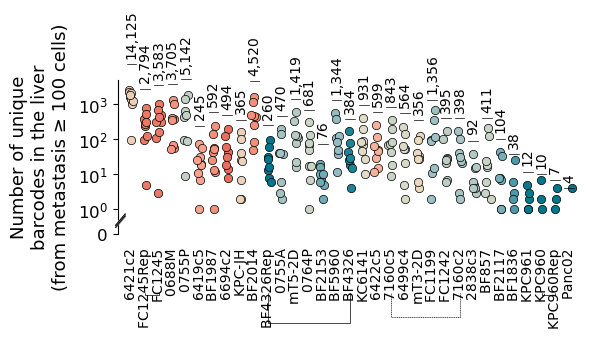

In [48]:
name = 'n_unique_barcodes_liver_exp2'
si = 'si'

plt.figure(figsize=(6, 2))
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_linewidth(0.5)

n = 0

# count unique barcodes per clID per mouse
n_tumors = mouse_clID_barcode_size_liver_2[mouse_clID_barcode_size_liver_2['size'] >= 100].groupby(['mouse', 'clID'])['barcode'].nunique().reset_index(name='n_barcodes')

clID__n_tumors = {clID: [] for clID in clIDs_no_spikein}
for clID in clIDs[1:]:
    values = n_tumors[n_tumors['clID'] == clID]['n_barcodes'].tolist()
    clID__n_tumors[clID].extend(values)

for i, clID in enumerate(clIDs_sorted_liver_2):
    plt.scatter(i + np.random.normal(0, 0.1, len(clID__n_tumors[clID])), [0.2 if x == 0 else x for x in clID__n_tumors[clID]], 
                color=clID__color_2[clID], edgecolor='black', linewidth=0.5, clip_on=False)
    
    
    if sum(clID__n_tumors[clID]) > 0:
        plt.plot([i - 0.35, i + 0.35], [sum(clID__n_tumors[clID]), sum(clID__n_tumors[clID])], color='black', linewidth=0.5, clip_on=False)
        if sum(clID__n_tumors[clID]) >= 1e4:
            plt.text(i, 1.5 * sum(clID__n_tumors[clID]), str(sum(clID__n_tumors[clID]))[:2] + ',' + str(sum(clID__n_tumors[clID]))[2:], va='bottom', ha='center', rotation=90)
        elif sum(clID__n_tumors[clID]) >= 1e3:
            plt.text(i, 1.5 * sum(clID__n_tumors[clID]), str(sum(clID__n_tumors[clID]))[0] + ',' + str(sum(clID__n_tumors[clID]))[1:], va='bottom', ha='center', rotation=90)
        else:
            plt.text(i, 1.5 * sum(clID__n_tumors[clID]), str(sum(clID__n_tumors[clID])), va='bottom', ha='center', rotation=90)
        
        n += sum(clID__n_tumors[clID])
        
    else:
        plt.plot([i - 0.35, i + 0.35], [0.2, 0.2], color='black', linewidth=0.5, clip_on=False, zorder=1)
        plt.text(i, 1.5 * 0.2, str(sum(clID__n_tumors[clID])), va='bottom', ha='center', rotation=90)

plt.yscale('log')
plt.minorticks_off()

plt.ylim(2e-1, 5e3)
plt.xlim(-1, i + 1)
    
# make sure that the order is correct
plt.xticks(range(len(clIDs_sorted_liver_2)), []);
plt.gca().set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted_liver_2], size=10, rotation=90)
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')
plt.yticks([2e-1, 1e0, 1e1, 1e2, 1e3], ['0', '$10^{0}$', '$10^{1}$', '$10^{2}$', '$10^{3}$'], size=12)


for i in np.logspace(np.log10(0.35), np.log10(0.4), 10):
    plt.text(-1.4, i, '|', rotation=-40, size=12, color='white')
plt.text(-1.4, 0.35, '|', rotation=-40, size=12)
plt.text(-1.4, 0.4, '|', rotation=-40, size=12)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted_liver_2.index(key[0]), clIDs_sorted_liver_2.index(key[1])])
    plt.annotate('', xy=(x[0], 0.005), xycoords='data', xytext=(x[1], 0.005), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

plt.ylabel('Number of unique\nbarcodes in the liver\n(from metastasis ≥ 100 cells)', fontsize=13, labelpad=6);

print(n)

plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

#### Size distributions

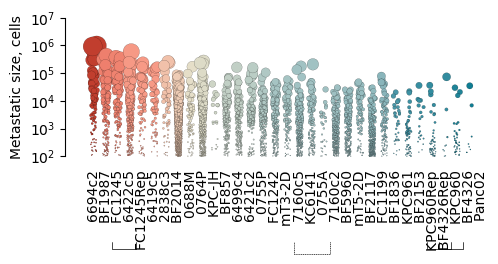

In [49]:
name = 'size_scatters_3w_f1_lung_exp1'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted):
    sizes = mouse_clID_barcode_size.loc[mouse_clID_barcode_size.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_1[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Metastatic size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

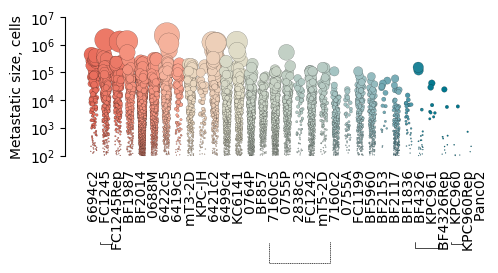

In [50]:
name = 'size_scatters_3w_f1_lung_exp2'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted_2):
    sizes = mouse_clID_barcode_size_2.loc[mouse_clID_barcode_size_2.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_2[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Metastatic size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted_2))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted_2], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted_2.index(key[0]), clIDs_sorted_2.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

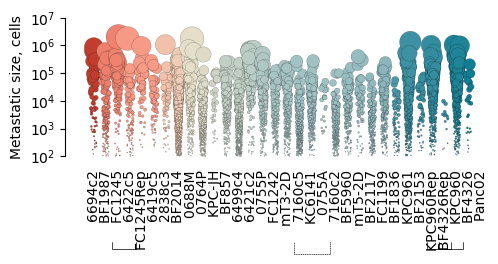

In [51]:
name = 'size_scatters_3w_rag1_lung_exp1'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted):
    sizes = mouse_clID_barcode_size_rag1.loc[mouse_clID_barcode_size_rag1.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_1[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Metastatic size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

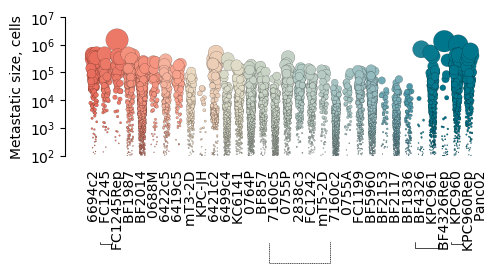

In [52]:
name = 'size_scatters_3w_rag1_lung_exp2'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted_2):
    sizes = mouse_clID_barcode_size_rag1_2.loc[mouse_clID_barcode_size_rag1_2.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_2[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Metastatic size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted_2))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted_2], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted_2.index(key[0]), clIDs_sorted_2.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

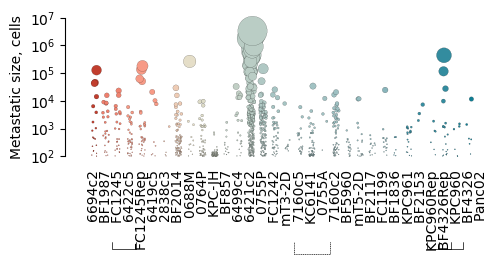

In [53]:
name = 'size_scatters_liver_exp1'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted):
    sizes = mouse_clID_barcode_size_liver.loc[mouse_clID_barcode_size_liver.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_1[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Metastatic size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

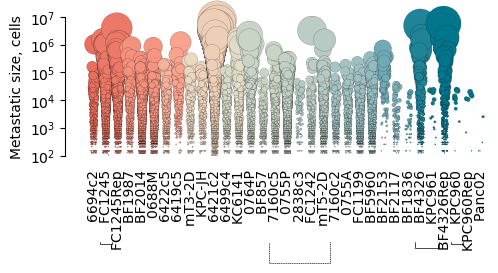

In [54]:
name = 'size_scatters_liver_exp2'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted_2):
    sizes = mouse_clID_barcode_size_liver_2.loc[mouse_clID_barcode_size_liver_2.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_2[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Metastatic size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted_2))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted_2], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted_2.index(key[0]), clIDs_sorted_2.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

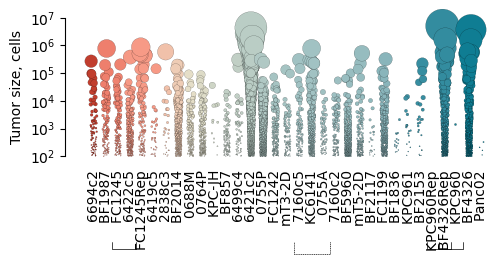

In [55]:
name = 'size_scatters_pancreas_exp1'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted):
    sizes = mouse_clID_barcode_size_pancreas.loc[mouse_clID_barcode_size_pancreas.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_1[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Tumor size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

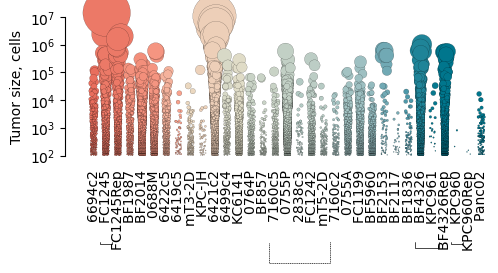

In [56]:
name = 'size_scatters_pancreas_exp2'
si = 'si'

plt.figure(figsize=(5, 1.8))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted_2):
    sizes = mouse_clID_barcode_size_pancreas_2.loc[mouse_clID_barcode_size_pancreas_2.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_2[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Tumor size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted_2))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted_2], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted_2.index(key[0]), clIDs_sorted_2.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig4/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 